In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply
plt.rcParams['figure.facecolor']='white'

In [2]:
# a single point is arranged along the last axis [i_1,i_2,...,i_d,:]
def delta_multivar(x, omega):
    # computes multivariate delta function on each point
    assert omega > 0
    return np.prod(delta_1d(x, omega), axis=-1)
def delta_1d(x, omega):
    assert omega > 0
    return (np.abs(x) <= omega) *  beta_2(x / omega) / omega
def beta(x):
    return 1 - np.abs(x)
def beta_2(x):
    return (1 + np.cos(np.pi * x)) / 2
def beta_3(x):
    return 2

# Solving simple ODEs by representing it as a linear PDE

In [15]:
M = 2
N = 2048
N_p = N
m = 1

R = 1

h = R/(N-1)
omega = (m * h) ** (1/2)

q = np.linspace(0, R, N)

X_0 = 0.2

In [22]:
# psi_0 = delta_1d(q - X_0, omega)
psi_0 = np.exp(-((q - X_0) / (0.03))**2)
# print(np.linalg.norm(psi_0))
psi_0 /= np.linalg.norm(psi_0)

In [23]:

dist = np.abs(psi_0) ** 2
print(np.sum(dist * q))

0.2


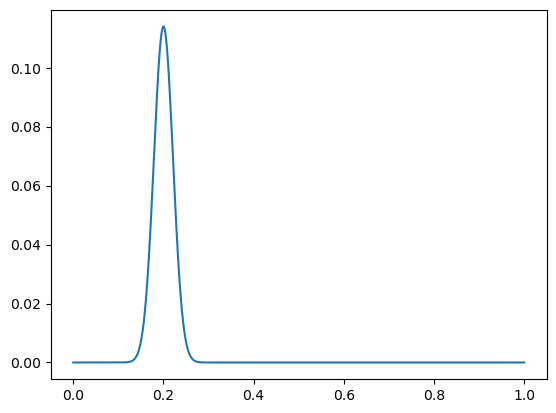

In [24]:
plt.plot(q, psi_0)
plt.show()

In [25]:
T = 1
N_t = 20
times = np.linspace(0, T, N_t)

In [26]:
def F_exp(q):
    return q

def F_minus_exp(q):
    return -q

def F_sq(q):
    return -q ** 2

def F_minus_sq(q):
    return -q ** 2

def F_const(q):
    return np.ones_like(q)

In [27]:
def solve(F, q, psi_0, h, N_t):
    H = diags([-1j * F(q[1:]), 1j * F(q[1:])], offsets=[1 ,-1]) / (2 * h)

    psi = expm_multiply(-1j * H, psi_0, 0, T, N_t)

    X = np.zeros(N_t)
    for i in range(N_t):
        dist = np.abs(psi[i]) ** 2
        X[i] = np.sum(dist * q)
    return X
# H = diags([-1j * G(q[1:]), 1j * G(q[1:])], offsets=[1 ,-1]) / (2 * h)

In [28]:
# more time points and try to exclude endpoint to avoid division by zero
fine_times = np.linspace(0, T - 1e-3, 100)

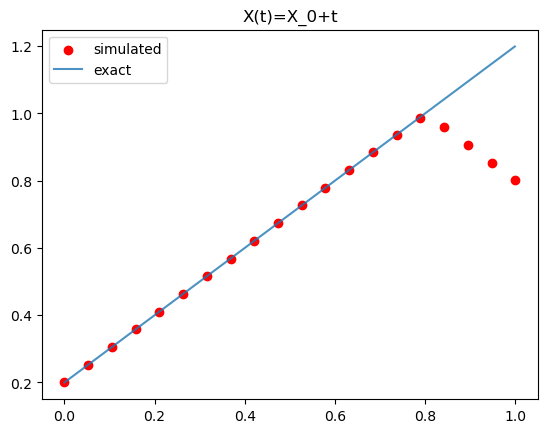

In [29]:
X = solve(F_const, q, psi_0, h, N_t)


plt.scatter(times, X, label="simulated", color="red")
plt.plot(fine_times, X_0+fine_times, label="exact", alpha=0.8)
plt.title("X(t)=X_0+t")
plt.legend()
plt.show()

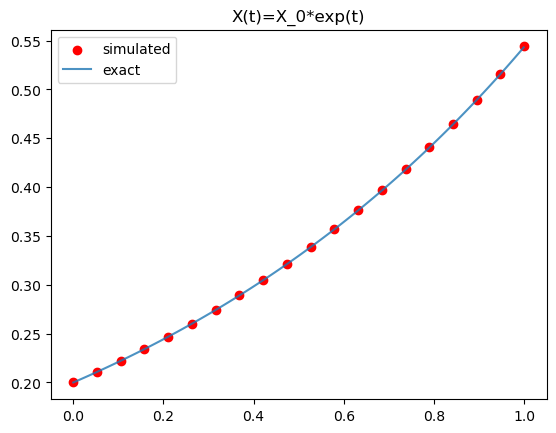

In [30]:
X = solve(F_exp, q, psi_0, h, N_t)


plt.scatter(times, X, label="simulated", color="red")
plt.plot(fine_times, X_0 * np.exp(fine_times), label="exact", alpha=0.8)
plt.title("X(t)=X_0*exp(t)")
plt.legend()
plt.show()

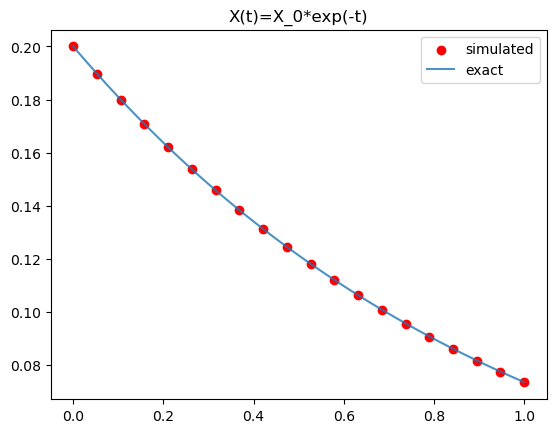

In [31]:
X = solve(F_minus_exp, q, psi_0, h, N_t)

plt.scatter(times, X, label="simulated", color="red")
plt.plot(fine_times, X_0 * np.exp(-fine_times), label="exact", alpha=0.8)
plt.title("X(t)=X_0*exp(-t)")
plt.legend()
plt.show()

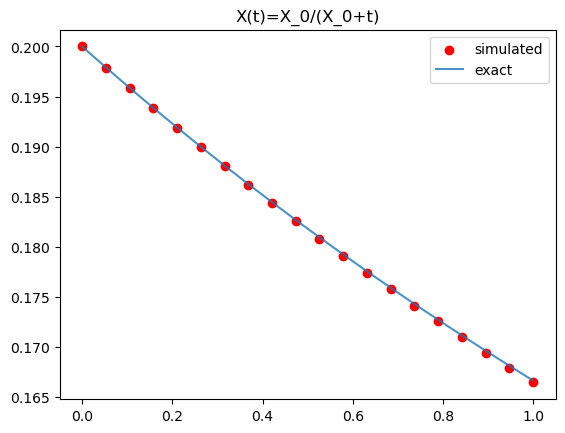

In [32]:
X = solve(F_minus_sq, q, psi_0, h, N_t)

plt.scatter(times, X, label="simulated", color="red")
plt.plot(fine_times, X_0 / (1 + X_0 * fine_times), label="exact", alpha=0.8)
plt.title("X(t)=X_0/(X_0+t)")
plt.legend()
plt.show()